In [ ]:
# ==========================================================
# UNZIP DATASET
# ==========================================================

import zipfile
import os

zip_path = "/content/EuroSAT_RGB.zip"
extract_path = "/content/EuroSAT"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

In [ ]:
import os

print(os.listdir("/content/EuroSAT/EuroSAT_RGB"))

In [ ]:
import os

print(os.listdir("/content/EuroSAT"))

In [ ]:
# ==========================================================
# PART 1 : IMPORTS & CONFIGURATION
# ==========================================================

import os
import random
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Random Seed
# ----------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ----------------------------------------------------------
# Mixed Precision (Recommended for T4 GPU)
# ----------------------------------------------------------

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print("Mixed Precision:", mixed_precision.global_policy())

# ----------------------------------------------------------
# Dataset Paths
# ----------------------------------------------------------

ZIP_PATH = "/content/EuroSAT_RGB.zip"

EXTRACT_PATH = "/content/EuroSAT"

DATASET_PATH = "/content/EuroSAT"

# ----------------------------------------------------------
# Image Configuration
# ----------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH = 224

IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# ----------------------------------------------------------
# Training Configuration
# ----------------------------------------------------------

BATCH_SIZE = 8

AUTOTUNE = tf.data.AUTOTUNE

INITIAL_EPOCHS = 15

FINE_TUNE_EPOCHS = 10

print("=" * 60)
print("TensorFlow :", tf.__version__)
print("Image Size :", IMG_SIZE)
print("Batch Size :", BATCH_SIZE)
print("=" * 60)

Mixed Precision: <DTypePolicy "mixed_float16">
TensorFlow : 2.20.0
Image Size : (224, 224)
Batch Size : 8


In [ ]:
# ==========================================================
# PART 2 : EXTRACT DATASET
# ==========================================================

import os
import zipfile

# ----------------------------------------------------------
# Extract Dataset (only if not already extracted)
# ----------------------------------------------------------

if not os.path.exists(EXTRACT_PATH):

    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("Dataset extracted successfully!")

else:
    print("Dataset already extracted.")

# ----------------------------------------------------------
# Find actual dataset folder automatically
# ----------------------------------------------------------

possible_paths = [
    "/content/EuroSAT",
    "/content/EuroSAT/EuroSAT_RGB",
    "/content/EuroSAT/2750"
]

DATASET_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        folders = [
            f for f in os.listdir(path)
            if os.path.isdir(os.path.join(path, f))
        ]

        # EuroSAT has 10 class folders
        if len(folders) >= 10:
            DATASET_PATH = path
            break

if DATASET_PATH is None:
    raise Exception("Dataset folder not found!")

print("\nDataset Path:")
print(DATASET_PATH)

print("\nClasses Found:")
print(os.listdir(DATASET_PATH))

Dataset already extracted.

Dataset Path:
/content/EuroSAT/EuroSAT_RGB

Classes Found:
['Forest', 'AnnualCrop', 'HerbaceousVegetation', 'River', 'SeaLake', 'Industrial', 'PermanentCrop', 'Pasture', 'Residential', 'Highway']


In [ ]:
# ==========================================================
# PART 3 : LOAD DATASET
# ==========================================================

import tensorflow as tf

# ----------------------------------------------------------
# Training Dataset (70%)
# ----------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

# ----------------------------------------------------------
# Temporary Dataset (30%)
# ----------------------------------------------------------

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

# ----------------------------------------------------------
# Split into Validation (15%) and Test (15%)
# ----------------------------------------------------------

total_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_batches = total_batches // 2

val_ds = temp_ds.take(val_batches)

test_ds = temp_ds.skip(val_batches)

# ----------------------------------------------------------
# Class Names
# ----------------------------------------------------------

CLASS_NAMES = train_ds.class_names

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(f"Number of Classes : {NUM_CLASSES}")

print("\nClass Names:")

for i, cls in enumerate(CLASS_NAMES):
    print(f"{i+1}. {cls}")

print("\nTraining Batches   :", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation Batches :", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing Batches    :", tf.data.experimental.cardinality(test_ds).numpy())

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
DATASET LOADED SUCCESSFULLY
Number of Classes : 10

Class Names:
1. AnnualCrop
2. Forest
3. HerbaceousVegetation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake

Training Batches   : 2363
Validation Batches : 506
Testing Batches    : 507


In [ ]:
# ==========================================================
# PART 4 : DATA AUGMENTATION & DATA PIPELINE
# ==========================================================

from tensorflow.keras import layers

# ----------------------------------------------------------
# Data Augmentation
# ----------------------------------------------------------

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.10),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomContrast(0.10)

], name="data_augmentation")

# ----------------------------------------------------------
# Optimize Dataset Pipeline
# ----------------------------------------------------------
# IMPORTANT:
# Do NOT use .cache() on Colab Free.
# It may cause RAM exhaustion.
# ----------------------------------------------------------

train_ds = (
    train_ds
    .shuffle(1000, seed=SEED)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Data pipeline ready.")

Data pipeline ready.


In [ ]:
# ==========================================================
# PART 5 : BUILD RESNET50 MODEL
# ==========================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

# ----------------------------------------------------------
# Load Pretrained ResNet50
# ----------------------------------------------------------

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# ----------------------------------------------------------
# Build Model
# ----------------------------------------------------------

inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Data Augmentation
x = data_augmentation(inputs)

# ResNet50 preprocessing
x = preprocess_input(x)

# Feature extraction
x = base_model(x, training=False)

# Classification Head
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

# Final Model
resnet_model = Model(inputs, outputs)

# ----------------------------------------------------------
# Model Summary
# ----------------------------------------------------------

print("="*60)
print("RESNET50 MODEL SUMMARY")
print("="*60)

resnet_model.summary()

RESNET50 MODEL SUMMARY


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,778,890 (94.52 MB)

 Trainable params: 1,187,082 (4.53 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
# ==========================================================
# PART 6 : TRAIN RESNET50 (FROZEN BASE)
# ==========================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ----------------------------------------------------------
# Callbacks
# ----------------------------------------------------------

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath="best_resnet50.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# ----------------------------------------------------------
# Compile Model
# ----------------------------------------------------------

resnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ----------------------------------------------------------
# Train
# ----------------------------------------------------------

print("=" * 60)
print("TRAINING RESNET50 (FROZEN BASE)")
print("=" * 60)

history = resnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=INITIAL_EPOCHS,

    callbacks=callbacks,

    verbose=1

)

TRAINING RESNET50 (FROZEN BASE)
Epoch 1/15
2363/2363 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6387 - loss: 1.1256
Epoch 1: val_accuracy improved from None to 0.93132, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
2363/2363 ━━━━━━━━━━━━━━━━━━━━ 137s 46ms/step - accuracy: 0.7535 - loss: 0.7609 - val_accuracy: 0.9313 - val_loss: 0.2112 - learning_rate: 1.0000e-04
Epoch 2/15
2363/2363 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8391 - loss: 0.4901
Epoch 2: val_accuracy improved from 0.93132 to 0.94121, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
2363/2363 ━━━━━━━━━━━━━━━━━━━━ 105s 42ms/step - accuracy: 0.8470 - loss: 0.4644 - val_accuracy: 0.9412 - val_loss: 0.1832 - learning_rate: 1.0000e-04
Epoch 3/15
2363/2363 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8667 - loss: 0.4171
Epoch 3: val_accuracy improved from 0.94121 to 0.94960, saving model to best_resnet50.keras

Epoch 3: finished

In [ ]:

# ==========================================================
# PART 7 : FINE-TUNE RESNET50
# ==========================================================

# ----------------------------------------------------------
# Unfreeze Base Model
# ----------------------------------------------------------

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable Layers:")

for layer in base_model.layers[-30:]:
    print(layer.name, ":", layer.trainable)

# ----------------------------------------------------------
# Recompile with Lower Learning Rate
# ----------------------------------------------------------

resnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("=" * 60)
print("FINE TUNING RESNET50")
print("=" * 60)

# ----------------------------------------------------------
# Fine Tune
# ----------------------------------------------------------

history_finetune = resnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=callbacks,

    verbose=1

)

Trainable Layers:
conv5_block1_1_relu : True
conv5_block1_2_conv : True
conv5_block1_2_bn : True
conv5_block1_2_relu : True
conv5_block1_0_conv : True
conv5_block1_3_conv : True
conv5_block1_0_bn : True
conv5_block1_3_bn : True
conv5_block1_add : True
conv5_block1_out : True
conv5_block2_1_conv : True
conv5_block2_1_bn : True
conv5_block2_1_relu : True
conv5_block2_2_conv : True
conv5_block2_2_bn : True
conv5_block2_2_relu : True
conv5_block2_3_conv : True
conv5_block2_3_bn : True
conv5_block2_add : True
conv5_block2_out : True
conv5_block3_1_conv : True
conv5_block3_1_bn : True
conv5_block3_1_relu : True
conv5_block3_2_conv : True
conv5_block3_2_bn : True
conv5_block3_2_relu : True
conv5_block3_3_conv : True
conv5_block3_3_bn : True
conv5_block3_add : True
conv5_block3_out : True
FINE TUNING RESNET50
Epoch 1/10
2363/2363 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8910 - loss: 0.3375
Epoch 1: val_accuracy improved from 0.96542 to 0.96838, saving model to best_resnet50.keras

Epoch

507/507 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.9766 - loss: 0.0709

Test Accuracy : 0.9766
Test Loss     : 0.0709

Classification Report

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.96      0.96       439
              Forest       0.99      1.00      0.99       445
HerbaceousVegetation       0.97      0.97      0.97       439
             Highway       0.94      0.99      0.96       373
          Industrial       0.99      0.98      0.98       383
             Pasture       0.98      0.97      0.98       266
       PermanentCrop       0.95      0.96      0.95       381
         Residential       0.98      0.99      0.99       431
               River       0.99      0.95      0.97       419
             SeaLake       1.00      0.99      0.99       476

            accuracy                           0.98      4052
           macro avg       0.98      0.98      0.98      4052
        weighted avg       0.98      0.98   

<Figure size 1000x1000 with 0 Axes>

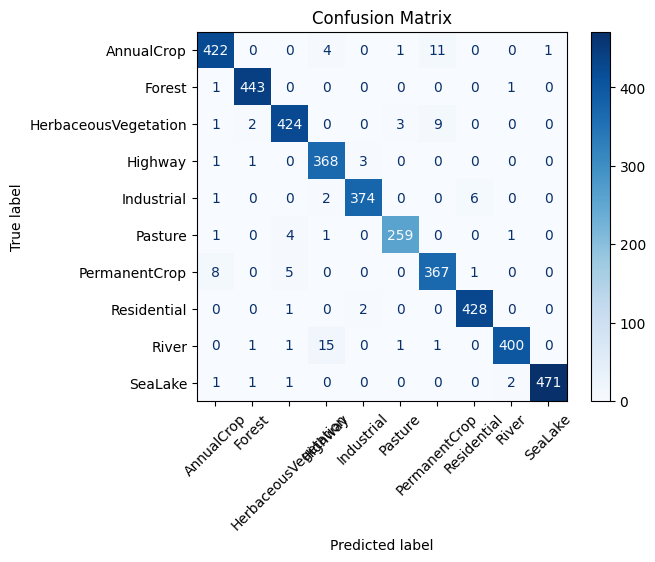

In [ ]:
# ==========================================================
# PART 8 : MODEL EVALUATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Evaluate Model
# ----------------------------------------------------------

test_loss, test_accuracy = resnet_model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "="*60)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("="*60)

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = resnet_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ==========================================================
# PART 9 : SINGLE IMAGE PREDICTION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# ----------------------------------------------------------
# Prediction Function
# ----------------------------------------------------------

def predict_image(image_path):

    # Load image
    img = image.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    img_array = image.img_to_array(img)

    img_batch = np.expand_dims(img_array, axis=0)

    # ResNet50 preprocessing
    img_batch = preprocess_input(img_batch)

    # Prediction
    predictions = resnet_model.predict(img_batch, verbose=0)

    probabilities = predictions[0]

    predicted_index = np.argmax(probabilities)

    predicted_class = CLASS_NAMES[predicted_index]

    confidence = probabilities[predicted_index] * 100

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()

    # Print all probabilities
    print("=" * 60)
    print("Prediction Probabilities")
    print("=" * 60)

    for cls, prob in zip(CLASS_NAMES, probabilities):
        print(f"{cls:<25} : {prob*100:.2f}%")

    return predicted_class, confidence

In [ ]:
import os

print(os.path.exists("/content/test.jpg"))

False


In [ ]:
from google.colab import files

uploaded = files.upload()


import os

print(os.listdir("/content"))

Saving download (3).jpg to download (3).jpg
['.config', 'download (3).jpg', '.ipynb_checkpoints', 'EuroSAT_RGB.zip', 'EuroSAT', 'best_resnet50.keras', 'sample_data']


In [ ]:
# ==========================================================
# PART 9 : SINGLE IMAGE PREDICTION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# ----------------------------------------------------------
# Prediction Function
# ----------------------------------------------------------

def predict_image(image_path):

    # Load image
    img = image.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    # Convert to array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # ResNet50 preprocessing
    img_array = preprocess_input(img_array)

    # Prediction
    predictions = resnet_model.predict(img_array, verbose=0)

    probabilities = predictions[0]

    predicted_index = np.argmax(probabilities)

    predicted_class = CLASS_NAMES[predicted_index]

    confidence = probabilities[predicted_index] * 100

    # Print Result
    print("=" * 60)
    print("PREDICTION RESULT")
    print("=" * 60)

    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.2f}%")

    print("\nClass Probabilities")
    print("-" * 60)

    for cls, prob in zip(CLASS_NAMES, probabilities):
        print(f"{cls:<25} : {prob*100:.2f}%")

    return predicted_class, confidence

Saving agriculture.jpg to agriculture (1).jpg


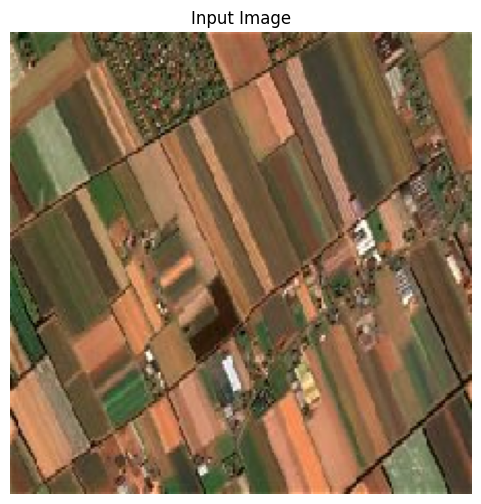

PREDICTION RESULT
Predicted Class : AnnualCrop
Confidence      : 59.57%

Class Probabilities
------------------------------------------------------------
AnnualCrop                : 59.57%
Forest                    : 7.66%
HerbaceousVegetation      : 0.00%
Highway                   : 0.06%
Industrial                : 24.61%
Pasture                   : 0.01%
PermanentCrop             : 6.15%
Residential               : 0.00%
River                     : 1.00%
SeaLake                   : 0.92%


('AnnualCrop', np.float32(59.569168))

In [ ]:
# ==========================================================
# PART 9 : UPLOAD + PREDICT
# ==========================================================

from google.colab import files
import os

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image_path = os.path.join("/content", image_name)

predict_image(image_path)

In [ ]:
# ==========================================================
# PART 10 : SAVE & LOAD MODEL
# ==========================================================

from tensorflow.keras.models import load_model

# ----------------------------------------------------------
# Save Model
# ----------------------------------------------------------

MODEL_PATH = "land_cover_resnet50.keras"

resnet_model.save(MODEL_PATH)

print("Model saved successfully!")
print("Saved at:", MODEL_PATH)

# ----------------------------------------------------------
# Load Model
# ----------------------------------------------------------

loaded_model = load_model(MODEL_PATH)

print("\nModel loaded successfully!")

# ----------------------------------------------------------
# Verify Model
# ----------------------------------------------------------

loaded_model.summary()

Model saved successfully!
Saved at: land_cover_resnet50.keras

Model loaded successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,053,412 (213.83 MB)

 Trainable params: 15,637,258 (59.65 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

 Optimizer params: 31,274,522 (119.30 MB)